In [2]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv('anime.csv')

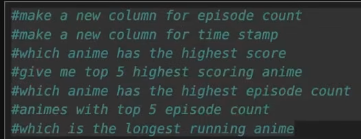

In [4]:
df.head() 
# shows top 5 rows

,Rank,Title,Score
0,1,Fullmetal Alchemist: BrotherhoodTV (64 eps)Apr...,9.10
1,2,"Steins;GateTV (24 eps)Apr 2011 - Sep 20112,473...",9.07
2,3,Bleach: Sennen Kessen-henTV (13 eps)Oct 2022 -...,9.06
3,4,"Gintama°TV (51 eps)Apr 2015 - Mar 2016605,113 ...",9.06
4,5,Shingeki no Kyojin Season 3 Part 2TV (10 eps)A...,9.05


In [5]:
df.loc[2]['Title']

'Bleach: Sennen Kessen-henTV (13 eps)Oct 2022 - Dec 2022474,138 members'

In [6]:
def extract_episodes(txt):
    check = False
    data = ""
    for i in txt:
        if i == ')':
            return data
        if check == True:
            data = data + i
        if i == '(':
            check = True
    return data
# logic behind it we have created check as false at first because by default it is needed to be false ton start the extraction process now we have run a loop to check the data and we have setted up conditions too 



In [7]:
df['Title'].apply(extract_episodes)

0      64 eps
1      24 eps
2      13 eps
3      51 eps
4      10 eps
5      51 eps
6       1 eps
7     148 eps
8      13 eps
9      13 eps
10      2 eps
11    110 eps
12     13 eps
13     13 eps
14     12 eps
15    201 eps
16      1 eps
17     22 eps
18     24 eps
19     25 eps
20      1 eps
21      1 eps
22      7 eps
23     14 eps
24     74 eps
25      1 eps
26      1 eps
27     12 eps
28      1 eps
29     24 eps
30     23 eps
31     12 eps
32     26 eps
33     13 eps
34     16 eps
35     11 eps
36      1 eps
37     11 eps
38     10 eps
39      1 eps
40     26 eps
41     12 eps
42     75 eps
43     26 eps
44     26 eps
45     24 eps
46     10 eps
47     12 eps
48     12 eps
49      4 eps
Name: Title, dtype: str

In [8]:
# lets create a new column as per the question
df['Episodes'] = df['Title'].apply(extract_episodes)

In [9]:
# did this because if we kept that we could not run aggregation functions
df['Episodes'] = df['Episodes'].str.replace("eps",' ')

In [10]:
df.head()

,Rank,Title,Score,Episodes
0,1,Fullmetal Alchemist: BrotherhoodTV (64 eps)Apr...,9.10,64
1,2,"Steins;GateTV (24 eps)Apr 2011 - Sep 20112,473...",9.07,24
2,3,Bleach: Sennen Kessen-henTV (13 eps)Oct 2022 -...,9.06,13
3,4,"Gintama°TV (51 eps)Apr 2015 - Mar 2016605,113 ...",9.06,51
4,5,Shingeki no Kyojin Season 3 Part 2TV (10 eps)A...,9.05,10


In [11]:
# converting in ints as its in string rn
df['Episodes'] = df['Episodes'].astype(int)

In [12]:
df['Episodes'].info()

<class 'pandas.Series'>
RangeIndex: 50 entries, 0 to 49
Series name: Episodes
Non-Null Count  Dtype
--------------  -----
50 non-null     int64
dtypes: int64(1)
memory usage: 532.0 bytes


In [13]:
df.loc[0]['Title']

'Fullmetal Alchemist: BrotherhoodTV (64 eps)Apr 2009 - Jul 20103,218,472 membersManga StoreVolume 1€4.58Preview'

In [14]:
# a new column for timestamp
def extract_timestamp(txt):
    check = False
    data = ""
    for i in range(len(txt)):
        if txt[i] == ")":
            for j in range(i+1,i+20):
                data += txt[j]

            return data
# logic of this loop like before we used check and data then this time we ran a loop till the range of len of txt then we used the if confition to check that there  is a bracket after txt[i] then we ran a loop from i+1 to i+20 then we stored that inside data



In [15]:
df['Title'].apply(extract_timestamp)

0     Apr 2009 - Jul 2010
1     Apr 2011 - Sep 2011
2     Oct 2022 - Dec 2022
3     Apr 2015 - Mar 2016
4     Apr 2019 - Jul 2019
5     Apr 2011 - Mar 2012
6     Jan 2021 - Jan 2021
7     Oct 2011 - Sep 2014
8     Apr 2022 - Jun 2022
9     Oct 2012 - Mar 2013
10    Mar 2023 - May 2023
11    Jan 1988 - Mar 1997
12    Jul 2023 - Aug 2023
13    Apr 2021 - Jun 2021
14    Jan 2017 - Mar 2017
15    Apr 2006 - Mar 2010
16    Sep 2016 - Sep 2016
17    Oct 2017 - Mar 2018
18    Oct 2008 - Mar 2009
19    Apr 2008 - Sep 2008
20    Jul 2013 - Jul 2013
21    Sep 2020 - Sep 2020
22    Aug 2017 - Aug 2017
23    Jul 2018 - Oct 2018
24    Apr 2004 - Sep 2005
25    Aug 2016 - Aug 2016
26    Dec 2022 - Dec 2022
27    Oct 2022 - Dec 2022
28    Dec 2022 - Dec 2022
29    Jan 2023 - Jun 2023
30    Jul 2023 - Aug 2023
31    Jan 2018 - Mar 2018
32    Apr 2020 - Oct 2021
33    Jan 2019 - Apr 2019
34    Dec 2020 - Mar 2021
35    Dec 2021 - Feb 2022
36    Jan 2017 - Jan 2017
37    Apr 2023 - Jun 2023
38    Oct 20

In [16]:
df['Time Stamp'] = df['Title'].apply(extract_timestamp)

In [17]:
df.head()

,Rank,Title,Score,Episodes,Time Stamp
0,1,Fullmetal Alchemist: BrotherhoodTV (64 eps)Apr...,9.10,64,Apr 2009 - Jul 2010
1,2,"Steins;GateTV (24 eps)Apr 2011 - Sep 20112,473...",9.07,24,Apr 2011 - Sep 2011
2,3,Bleach: Sennen Kessen-henTV (13 eps)Oct 2022 -...,9.06,13,Oct 2022 - Dec 2022
3,4,"Gintama°TV (51 eps)Apr 2015 - Mar 2016605,113 ...",9.06,51,Apr 2015 - Mar 2016
4,5,Shingeki no Kyojin Season 3 Part 2TV (10 eps)A...,9.05,10,Apr 2019 - Jul 2019


In [18]:
df[['Start Date','End Date']] = df['Time Stamp'].str.split('-',expand=True)

In [19]:
df.head()

,Rank,Title,Score,Episodes,Time Stamp,Start Date,End Date
0,1,Fullmetal Alchemist: BrotherhoodTV (64 eps)Apr...,9.10,64,Apr 2009 - Jul 2010,Apr 2009,Jul 2010
1,2,"Steins;GateTV (24 eps)Apr 2011 - Sep 20112,473...",9.07,24,Apr 2011 - Sep 2011,Apr 2011,Sep 2011
2,3,Bleach: Sennen Kessen-henTV (13 eps)Oct 2022 -...,9.06,13,Oct 2022 - Dec 2022,Oct 2022,Dec 2022
3,4,"Gintama°TV (51 eps)Apr 2015 - Mar 2016605,113 ...",9.06,51,Apr 2015 - Mar 2016,Apr 2015,Mar 2016
4,5,Shingeki no Kyojin Season 3 Part 2TV (10 eps)A...,9.05,10,Apr 2019 - Jul 2019,Apr 2019,Jul 2019


In [20]:
df['Start Date'] = pd.to_datetime(df['Start Date'])
df['End Date'] = pd.to_datetime(df['End Date'])

/tmp/ipykernel_143703/3068243806.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Start Date'] = pd.to_datetime(df['Start Date'])
/tmp/ipykernel_143703/3068243806.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['End Date'] = pd.to_datetime(df['End Date'])


In [21]:
year_diff = df['End Date'].dt.year - df['Start Date'].dt.year
month_diff = df['End Date'].dt.month - df['Start Date'].dt.month

In [22]:
df['Months Duration'] = year_diff+month_diff

In [23]:
df = df.drop(columns=['Start Date','End Date'])

In [26]:
df = df.drop('Duration',axis=1) #type = ignore

KeyError: "['Duration'] not found in axis"

In [ ]:
df.head()

,Rank,Title,Score,Episodes,Time Stamp,Months Duration
0,1,Fullmetal Alchemist: BrotherhoodTV (64 eps)Apr...,9.10,64,Apr 2009 - Jul 2010,4
1,2,"Steins;GateTV (24 eps)Apr 2011 - Sep 20112,473...",9.07,24,Apr 2011 - Sep 2011,5
2,3,Bleach: Sennen Kessen-henTV (13 eps)Oct 2022 -...,9.06,13,Oct 2022 - Dec 2022,2
3,4,"Gintama°TV (51 eps)Apr 2015 - Mar 2016605,113 ...",9.06,51,Apr 2015 - Mar 2016,0
4,5,Shingeki no Kyojin Season 3 Part 2TV (10 eps)A...,9.05,10,Apr 2019 - Jul 2019,3


In [25]:
# find out the anime with highest rating
df[df['Score'] == df['Score'].max()]

,Rank,Title,Score,Episodes,Time Stamp,Months Duration
0,1,Fullmetal Alchemist: BrotherhoodTV (64 eps)Apr...,9.1,64,Apr 2009 - Jul 2010,4


In [27]:
df[df['Episodes'] == df['Episodes'].max()]

,Rank,Title,Score,Episodes,Time Stamp,Months Duration
15,16,"GintamaTV (201 eps)Apr 2006 - Mar 20101,034,41...",8.94,201,Apr 2006 - Mar 2010,3


In [28]:
df['Score'].value_counts()

Score
9.04    4
8.79    3
9.06    2
9.03    2
8.99    2
8.94    2
8.93    2
8.91    2
8.88    2
8.84    2
8.83    2
8.82    2
8.81    2
8.80    2
8.78    2
8.77    2
8.75    2
8.71    2
9.10    1
9.07    1
9.05    1
9.02    1
8.98    1
8.89    1
8.87    1
8.76    1
8.74    1
8.73    1
8.72    1
Name: count, dtype: int64

In [30]:
df['Title'].head()

0    Fullmetal Alchemist: BrotherhoodTV (64 eps)Apr...
1    Steins;GateTV (24 eps)Apr 2011 - Sep 20112,473...
2    Bleach: Sennen Kessen-henTV (13 eps)Oct 2022 -...
3    Gintama°TV (51 eps)Apr 2015 - Mar 2016605,113 ...
4    Shingeki no Kyojin Season 3 Part 2TV (10 eps)A...
Name: Title, dtype: str

In [31]:
df[df['Months Duration'] == df['Months Duration'].max()]

,Rank,Title,Score,Episodes,Time Stamp,Months Duration
11,12,Ginga Eiyuu DensetsuOVA (110 eps)Jan 1988 - Ma...,9.02,110,Jan 1988 - Mar 1997,11
